# Hamiltonian Flow Matching - Two-Particle Spring Forward/Backward Test

This notebook transports Gaussian endpoint distributions on the 4D configuration
space of two particles in 2D,

$$q=(q_1^x,q_1^y,q_2^x,q_2^y)\in R^4,$$

under the zero-rest-length spring potential

$$U(q_1,q_2)=\frac{1}{2}\lVert q_2-q_1\rVert^2.$$

The training structure follows `examples/fwd_bwd_test.ipynb`: a forward model
transports source to target, a backward model transports target to source, and
alternating epochs solve fresh `MeanStdBVPGaussianPath` BVPs using the opposite
NODE trajectory as the initial mean and mean-derivative guess.

In [ ]:
import sys, os
sys.path.insert(0, os.path.abspath('../../../'))

import math
import torch
if torch.cuda.is_available() and torch.cuda.device_count() > 2:
    device = torch.device('cuda:2')
elif torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')

import numpy as np
import matplotlib.pyplot as plt
from torch.distributions import MultivariateNormal
from torchdyn.core import NeuralODE

from torchcfm.hamiltonian import MeanStdBVPGaussianPath, flow_matching_loss
from torchcfm.optimal_transport import OTPlanSampler
from torchcfm.models.models_v2 import MLP
from torchcfm.utils import torch_wrapper


def to_numpy(x):
    return x.detach().cpu().numpy()

In [67]:
torch.manual_seed(42)
np.random.seed(42)

# Configuration-space dimension: two 2D particles.
n_particles = 2
particle_dim = 2
dim = n_particles * particle_dim

# Training controls. These match the forward/backward reference notebook.
batch_size = 64
n_dataset = 128
n_epochs = 5
n_iters = 1000
n_warmup_iters = 10_000
batch_size_warmup = 1024
lr = 5e-4
sigma_path = 0.01
n_steps = 150
tol = 1e-5

kappa = 1.0
covariance = 0.1
gaussian_std = torch.tensor(math.sqrt(covariance), device=device)

source_mean = torch.tensor([0.0, 0.0, 5.0, 0.0], device=device)
target_mean = torch.tensor([5.0, 0.0, 0.0, 0.0], device=device)
solve_t_span = torch.linspace(0, 1, n_steps + 1, device=device)
eval_batch = 5000

print(f'device: {device}')
print(f'source mean: {source_mean.tolist()}')
print(f'target mean: {target_mean.tolist()}')

device: cuda:2
source mean: [0.0, 0.0, 5.0, 0.0]
target mean: [5.0, 0.0, 0.0, 0.0]


## Spring Potential

The particle Hamiltonian equations are

$$\dot q_1=p_1,\quad \dot q_2=p_2,$$

$$\dot p_1=q_2-q_1,\quad \dot p_2=q_1-q_2.$$

`MeanStdBVPGaussianPath` evaluates the configuration-space potential gradient
under Gaussian quadrature, so the local potential class exposes `gradient` and
`linear_gradient`.

In [68]:
class TwoParticleSpringPotential:
    def __init__(self, kappa=1.0):
        self.kappa = float(kappa)

    def _reshape(self, q):
        return q.reshape(q.shape[0], n_particles, particle_dim)

    def energy(self, q):
        q_particles = self._reshape(q)
        relative = q_particles[:, 1] - q_particles[:, 0]
        return 0.5 * self.kappa * (relative ** 2).sum(dim=-1)

    def gradient(self, q):
        original_shape = q.shape
        q_particles = self._reshape(q)
        relative = q_particles[:, 1] - q_particles[:, 0]
        grad = torch.empty_like(q_particles)
        grad[:, 0] = -self.kappa * relative
        grad[:, 1] = self.kappa * relative
        return grad.reshape(original_shape)

    def linear_gradient(self, q):
        return self.gradient(q)

    def force(self, q):
        return -self.gradient(q)


potential = TwoParticleSpringPotential(kappa=kappa)

q_test = source_mean.reshape(1, -1)
print(f'U(source_mean) = {potential.energy(q_test).item():.4f}')
print(f'force(source_mean) = {potential.force(q_test).reshape(n_particles, particle_dim)}')

U(source_mean) = 12.5000
force(source_mean) = tensor([[ 5.,  0.],
        [-5., -0.]], device='cuda:2')


## Endpoint Distributions

Both endpoint distributions live on configuration space, not phase space:

$$\rho_0 = N([0,0,0,1], 0.5 I_4),\quad
  \rho_1 = N([0,0,1,1], 0.5 I_4).$$

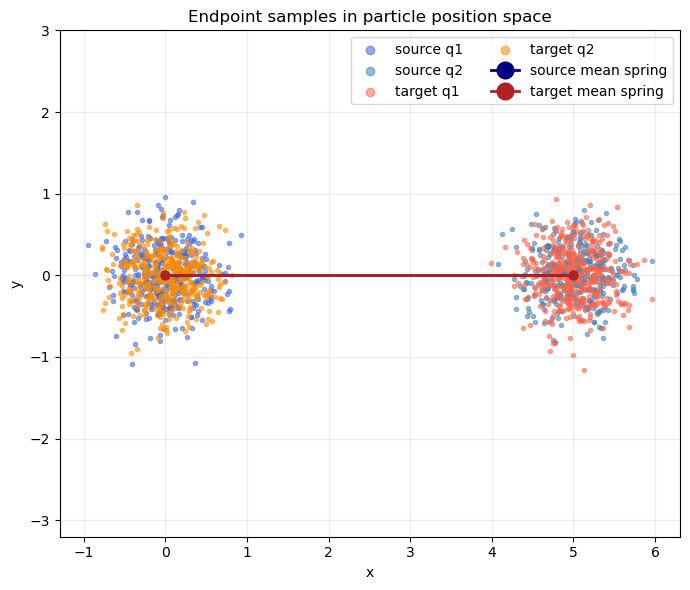

In [69]:
source_dist = MultivariateNormal(
    source_mean, covariance * torch.eye(dim, device=device)
)
target_dist = MultivariateNormal(
    target_mean, covariance * torch.eye(dim, device=device)
)


def sample_source(n):
    return source_dist.sample((n,)).to(device)


def sample_target(n):
    return target_dist.sample((n,)).to(device)


def as_particles(q):
    return q.reshape(*q.shape[:-1], n_particles, particle_dim)


def plot_particle_samples(x0, x1, title, n_show=400):
    x0p = to_numpy(as_particles(x0[:n_show]))
    x1p = to_numpy(as_particles(x1[:n_show]))

    plt.figure(figsize=(7, 6))
    plt.scatter(x0p[:, 0, 0], x0p[:, 0, 1], s=9, c='royalblue', alpha=0.55, label='source q1')
    plt.scatter(x0p[:, 1, 0], x0p[:, 1, 1], s=9, c='steelblue', alpha=0.55, label='source q2')
    plt.scatter(x1p[:, 0, 0], x1p[:, 0, 1], s=9, c='tomato', alpha=0.55, label='target q1')
    plt.scatter(x1p[:, 1, 0], x1p[:, 1, 1], s=9, c='darkorange', alpha=0.55, label='target q2')

    src = to_numpy(as_particles(source_mean.reshape(1, -1)))[0]
    tgt = to_numpy(as_particles(target_mean.reshape(1, -1)))[0]
    plt.plot(src[:, 0], src[:, 1], color='navy', linewidth=2.0, marker='o', label='source mean spring')
    plt.plot(tgt[:, 0], tgt[:, 1], color='firebrick', linewidth=2.0, marker='o', label='target mean spring')

    plt.axis('equal')
    plt.grid(alpha=0.25)
    plt.xlabel('x')
    plt.ylabel('y')
    plt.title(title)
    plt.legend(markerscale=2, ncols=2)
    plt.tight_layout()
    plt.show()


x0_vis = sample_source(500)
x1_vis = sample_target(500)
plot_particle_samples(x0_vis, x1_vis, 'Endpoint samples in particle position space')

## Closed-Form Mean Boundary-Value Check

For the endpoint means, center-of-mass and relative coordinates decouple:

$$c=(q_1+q_2)/2,\quad r=q_2-q_1,$$

$$\ddot c=0,\quad \ddot r=-2\kappa r.$$

This gives an analytic reference for the mean component of the Gaussian BVP.

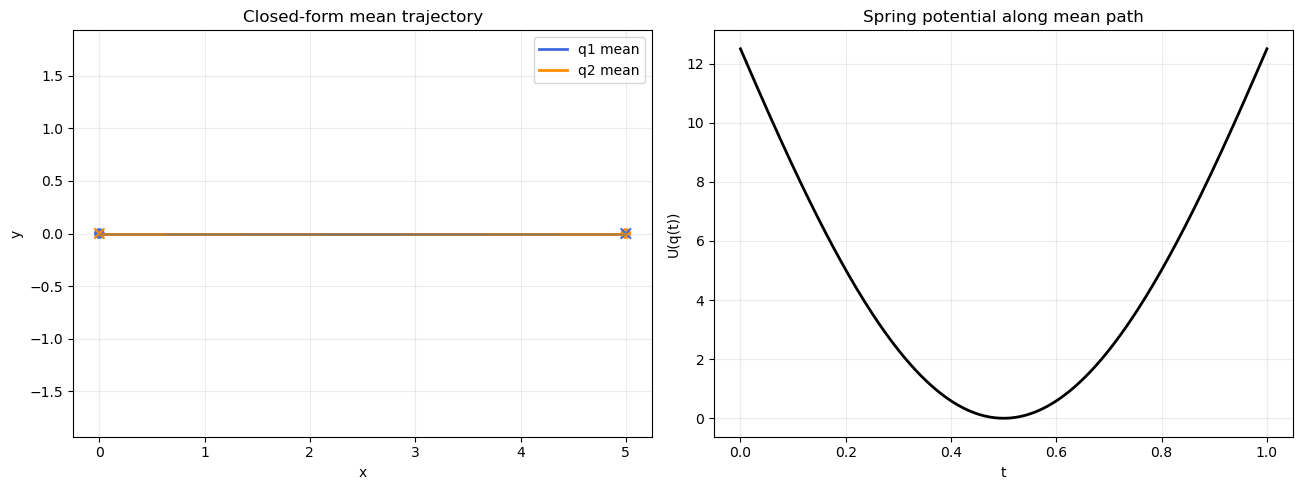

In [70]:
def closed_form_spring_mean(t, q0=source_mean, q1=target_mean, kappa=1.0):
    t = torch.as_tensor(t, dtype=q0.dtype, device=q0.device).reshape(-1, 1)
    q0p = as_particles(q0.reshape(1, -1))[0]
    q1p = as_particles(q1.reshape(1, -1))[0]

    c0 = 0.5 * (q0p[0] + q0p[1])
    c1 = 0.5 * (q1p[0] + q1p[1])
    r0 = q0p[1] - q0p[0]
    r1 = q1p[1] - q1p[0]

    omega = torch.as_tensor(math.sqrt(2.0 * kappa), dtype=q0.dtype, device=q0.device)
    rdot0 = omega / torch.sin(omega) * (r1 - torch.cos(omega) * r0)

    c_t = (1.0 - t) * c0 + t * c1
    r_t = torch.cos(omega * t) * r0 + torch.sin(omega * t) / omega * rdot0
    q1_t = c_t - 0.5 * r_t
    q2_t = c_t + 0.5 * r_t
    return torch.stack([q1_t, q2_t], dim=1).reshape(t.shape[0], dim)


t_plot = torch.linspace(0, 1, 200, device=device)
mean_path = closed_form_spring_mean(t_plot, kappa=kappa)
mean_particles = to_numpy(as_particles(mean_path))
mean_energy = to_numpy(potential.energy(mean_path))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(mean_particles[:, 0, 0], mean_particles[:, 0, 1], color='royalblue', linewidth=2.0, label='q1 mean')
axes[0].plot(mean_particles[:, 1, 0], mean_particles[:, 1, 1], color='darkorange', linewidth=2.0, label='q2 mean')
for idx in np.linspace(0, len(mean_particles) - 1, 8).astype(int):
    axes[0].plot(mean_particles[idx, :, 0], mean_particles[idx, :, 1], color='0.45', alpha=0.45, linewidth=1.0)
axes[0].scatter(mean_particles[0, :, 0], mean_particles[0, :, 1], c=['royalblue', 'darkorange'], s=45, marker='o')
axes[0].scatter(mean_particles[-1, :, 0], mean_particles[-1, :, 1], c=['royalblue', 'darkorange'], s=55, marker='x')
axes[0].axis('equal')
axes[0].grid(alpha=0.25)
axes[0].set_xlabel('x')
axes[0].set_ylabel('y')
axes[0].set_title('Closed-form mean trajectory')
axes[0].legend()

axes[1].plot(to_numpy(t_plot), mean_energy, color='black', linewidth=2.0)
axes[1].set_xlabel('t')
axes[1].set_ylabel('U(q(t))')
axes[1].set_title('Spring potential along mean path')
axes[1].grid(alpha=0.25)

plt.tight_layout()
plt.show()

## Model and BVP Helpers

`MeanStdBVPGaussianPath` stores states `[mu, mu_dot, sigma, sigma_dot]`. The helper
functions mirror `examples/fwd_bwd_test.ipynb`, with particle-specific plotting
and diagnostics for the spring system.

In [71]:
ot_sampler = OTPlanSampler(method='exact')

fwd_model = MLP(dim + 1, out_dim=dim, w=128).to(device)
bwd_model = MLP(dim + 1, out_dim=dim, w=128).to(device)
fwd_optimizer = torch.optim.Adam(fwd_model.parameters(), lr=lr)
bwd_optimizer = torch.optim.Adam(bwd_model.parameters(), lr=lr)

fwd_losses = []
bwd_losses = []


def make_node(model):
    return NeuralODE(torch_wrapper(model), sensitivity='adjoint', solver='euler')


def trajectory_to_guesses(traj, reverse=True):
    # traj has shape (time, batch, dim). The BVP path expects (batch, time, dim).
    if reverse:
        traj = torch.flip(traj, dims=(0,))
    traj = traj.detach()
    if traj.shape[0] != n_steps + 1:
        raise ValueError(f'Expected {n_steps + 1} trajectory time points, got {traj.shape[0]}.')

    dt = 1.0 / n_steps
    mu_dot = torch.empty_like(traj)
    mu_dot[0] = (traj[1] - traj[0]) / dt
    mu_dot[-1] = (traj[-1] - traj[-2]) / dt
    mu_dot[1:-1] = (traj[2:] - traj[:-2]) / (2.0 * dt)

    mu_guess = to_numpy(traj.permute(1, 0, 2).contiguous())
    mu_dot_guess = to_numpy(mu_dot.permute(1, 0, 2).contiguous())
    return mu_guess, mu_dot_guess


def make_path(mu_guess=None, mu_dot_guess=None):
    sigma_guess = None
    sigma_dot_guess = None
    if mu_guess is not None:
        n_pairs = mu_guess.shape[0]
        sigma_guess = np.full((n_pairs, n_steps + 1), sigma_path, dtype=float)
        sigma_dot_guess = np.zeros((n_pairs, n_steps + 1), dtype=float)

    return MeanStdBVPGaussianPath(
        potential,
        sigma=sigma_path,
        n_steps=n_steps,
        tol=tol,
        mu_guess=mu_guess,
        mu_dot_guess=mu_dot_guess,
        sigma_guess=sigma_guess,
        sigma_dot_guess=sigma_dot_guess,
    )


def solve_bvp_paths(x0, x1, mu_guess=None, mu_dot_guess=None, label='path'):
    path = make_path(mu_guess, mu_dot_guess)
    print(f'Solving {x0.shape[0]} {label} mean/std BVPs...')
    states = path.batch_solve(x0, x1)
    keep = path.success_mask.to(device=x0.device)
    x0_keep = x0[keep]
    x1_keep = x1[keep]
    n_failed = int((~keep).sum().item())
    print(f'{label}: kept {x0_keep.shape[0]} / {keep.numel()} BVPs; failed {n_failed}; states: {states.shape}')
    if n_failed:
        preview = list(path.failure_messages.items())[:5]
        print(f'{label}: first failures: {preview}')
    return path, x0_keep, x1_keep, states


def train_on_cached_paths(model, optimizer, path, x0, x1, n_steps_train, label, log_every=200):
    model.train()
    step_losses = []
    n_pairs = x0.shape[0]
    if n_pairs == 0:
        raise RuntimeError(f'{label}: no successful BVP pairs to train on.')

    x0 = x0.to(device)
    x1 = x1.to(device)
    for step in range(n_steps_train):
        optimizer.zero_grad()

        idx = torch.randint(0, n_pairs, (batch_size,), device=device)
        x0_b = x0[idx]
        x1_b = x1[idx]
        t = torch.rand((batch_size, 1), device=device, dtype=x0_b.dtype)
        epsilon = torch.randn_like(x0_b)

        xt = path.sample_xt(x0_b, x1_b, t, epsilon)
        ut = path.compute_ut(x0_b, x1_b, t, xt)
        vt = model(torch.cat([xt, t], dim=-1))
        loss = flow_matching_loss(vt, ut)

        loss.backward()
        optimizer.step()
        step_losses.append(loss.item())

        if step % log_every == 0 or step == n_steps_train - 1:
            print(f'{label} step {step:5d}: loss = {loss.item():.5f}')
    return step_losses


def train_on_ot_pairs(model, optimizer, x0, x1, n_steps_train, label, log_every=200):
    model.train()
    step_losses = []
    n_pairs = x0.shape[0]
    if n_pairs == 0:
        raise RuntimeError(f'{label}: no OT pairs to train on.')

    x0 = x0.to(device)
    x1 = x1.to(device)
    for step in range(n_steps_train):
        optimizer.zero_grad()

        idx = torch.randint(0, n_pairs, (batch_size,), device=device)
        x0_b = x0[idx]
        x1_b = x1[idx]
        t = torch.rand((batch_size, 1), device=device, dtype=x0_b.dtype)

        xt = (1.0 - t) * x0_b + t * x1_b
        ut = x1_b - x0_b
        vt = model(torch.cat([xt, t], dim=-1))
        loss = flow_matching_loss(vt, ut)

        loss.backward()
        optimizer.step()
        step_losses.append(loss.item())

        if step % log_every == 0 or step == n_steps_train - 1:
            print(f'{label} step {step:5d}: loss = {loss.item():.5f}')
    return step_losses

## Initial Mean/Std BVP Dataset

The initial cached dataset is useful for sanity checks and visualizing the
Gaussian mean and standard-deviation schedules before alternating training.

In [72]:
mean_path_solver = make_path()
mean_states = mean_path_solver.batch_solve(
    source_mean.reshape(1, -1),
    target_mean.reshape(1, -1),
)
mean_bvp_mu = mean_states[0, :, :dim].to(device)
mean_closed_mu = closed_form_spring_mean(mean_path_solver.t_grid.to(device), kappa=kappa)
max_mean_error = (mean_bvp_mu - mean_closed_mu).abs().max().item()
print(f'max |BVP mean path - closed form|: {max_mean_error:.3e}')
print(f'min sigma on mean BVP: {mean_states[0, :, 2 * dim].min().item():.3e}')

x0_all = sample_source(n_dataset)
x1_all = sample_target(n_dataset)
x0_coupled, x1_coupled = ot_sampler.sample_plan(x0_all, x1_all)
path, x0_coupled, x1_coupled, states = solve_bvp_paths(x0_coupled, x1_coupled, label='initial')
n_dataset = x0_coupled.shape[0]

max |BVP mean path - closed form|: 9.537e-07
min sigma on mean BVP: 1.000e-02
Solving 128 initial mean/std BVPs...
initial: kept 128 / 128 BVPs; failed 0; states: torch.Size([128, 151, 10])


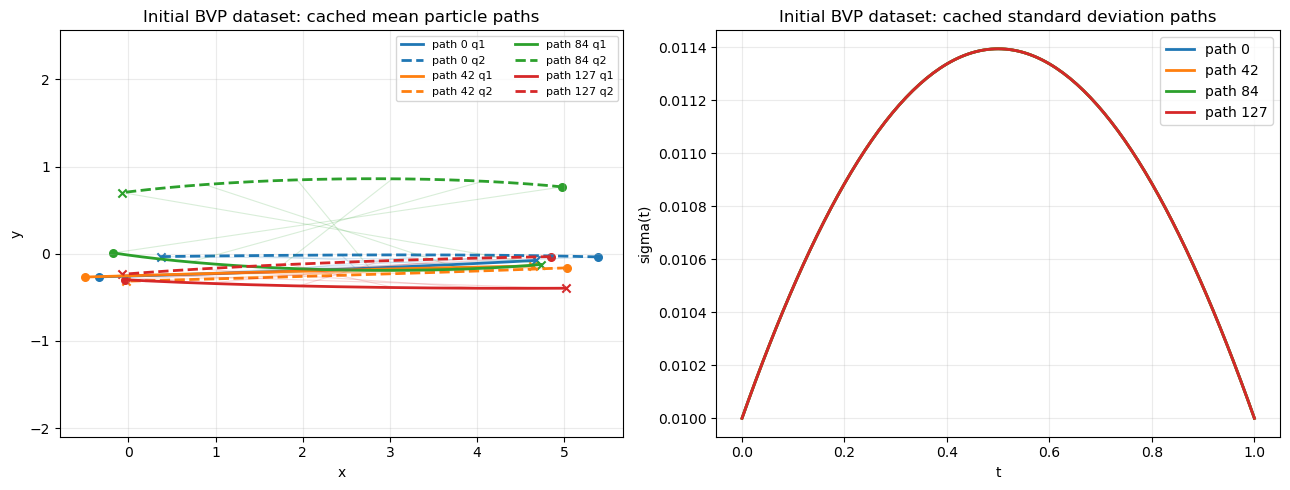

In [73]:
def plot_cached_mean_std_paths(path, states, title, n_mean_std_show=4):
    if states is None or states.shape[0] == 0:
        print(f'{title}: no cached states to plot.')
        return

    n_mean_std_show = min(n_mean_std_show, states.shape[0])
    plot_idx = torch.linspace(0, states.shape[0] - 1, n_mean_std_show).long()
    t_state = to_numpy(path.t_grid[:states.shape[1]])
    mean_paths = to_numpy(as_particles(states[plot_idx, :, :dim]))
    sigma_paths = to_numpy(states[plot_idx, :, 2 * dim])
    colors = plt.cm.tab10(np.arange(n_mean_std_show))

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    spring_idx = np.linspace(0, mean_paths.shape[1] - 1, 6).astype(int)
    for j, idx in enumerate(plot_idx.tolist()):
        color = colors[j]
        axes[0].plot(
            mean_paths[j, :, 0, 0], mean_paths[j, :, 0, 1],
            color=color, linewidth=2.0, label=f'path {idx} q1'
        )
        axes[0].plot(
            mean_paths[j, :, 1, 0], mean_paths[j, :, 1, 1],
            color=color, linestyle='--', linewidth=2.0, label=f'path {idx} q2'
        )
        axes[0].scatter(mean_paths[j, 0, :, 0], mean_paths[j, 0, :, 1], s=30, color=color, marker='o')
        axes[0].scatter(mean_paths[j, -1, :, 0], mean_paths[j, -1, :, 1], s=35, color=color, marker='x')
        for sidx in spring_idx:
            axes[0].plot(
                mean_paths[j, sidx, :, 0], mean_paths[j, sidx, :, 1],
                color=color, alpha=0.18, linewidth=0.8
            )

    axes[0].axis('equal')
    axes[0].grid(alpha=0.25)
    axes[0].set_xlabel('x')
    axes[0].set_ylabel('y')
    axes[0].set_title(f'{title}: cached mean particle paths')
    axes[0].legend(fontsize=8, ncols=2)

    for j, idx in enumerate(plot_idx.tolist()):
        axes[1].plot(t_state, sigma_paths[j], color=colors[j], linewidth=2.0, label=f'path {idx}')
    axes[1].set_xlabel('t')
    axes[1].set_ylabel('sigma(t)')
    axes[1].set_title(f'{title}: cached standard deviation paths')
    axes[1].grid(alpha=0.25)
    axes[1].legend()

    plt.tight_layout()
    plt.show()


plot_cached_mean_std_paths(path, states, 'Initial BVP dataset')

## Warmup on Zero-Potential OT Pairs

In [52]:
x0_warm = sample_source(batch_size_warmup)
x1_warm = sample_target(batch_size_warmup)
x0_warm, x1_warm = ot_sampler.sample_plan(x0_warm, x1_warm)

fwd_losses.extend(
    train_on_ot_pairs(
        fwd_model, fwd_optimizer, x0_warm, x1_warm,
        n_warmup_iters, label='warmup fwd'
    )
)
bwd_losses.extend(
    train_on_ot_pairs(
        bwd_model, bwd_optimizer, x1_warm, x0_warm,
        n_warmup_iters, label='warmup bwd'
    )
)

warmup fwd step     0: loss = 19.67070
warmup fwd step   200: loss = 0.01444
warmup fwd step   400: loss = 0.02161
warmup fwd step   600: loss = 0.01747
warmup fwd step   800: loss = 0.01198
warmup fwd step  1000: loss = 0.01057
warmup fwd step  1200: loss = 0.01050
warmup fwd step  1400: loss = 0.01117
warmup fwd step  1600: loss = 0.00915
warmup fwd step  1800: loss = 0.01209
warmup fwd step  2000: loss = 0.00929
warmup fwd step  2200: loss = 0.00933
warmup fwd step  2400: loss = 0.00886
warmup fwd step  2600: loss = 0.00905
warmup fwd step  2800: loss = 0.00997
warmup fwd step  3000: loss = 0.01047
warmup fwd step  3200: loss = 0.00775
warmup fwd step  3400: loss = 0.00856
warmup fwd step  3600: loss = 0.00877
warmup fwd step  3800: loss = 0.01393
warmup fwd step  4000: loss = 0.01088
warmup fwd step  4200: loss = 0.00767
warmup fwd step  4400: loss = 0.00856
warmup fwd step  4600: loss = 0.01137
warmup fwd step  4800: loss = 0.00971
warmup fwd step  5000: loss = 0.01001
warmup fwd 

## Alternating Forward/Backward Training

In [54]:
last_fwd_path = None
last_bwd_path = None
last_fwd_states = None
last_bwd_states = None
last_fwd_x0, last_fwd_x1 = None, None
last_bwd_x0, last_bwd_x1 = None, None

for epoch in range(n_epochs):
    if epoch % 2 == 0:
        # Train fwd using couplings induced by the current bwd NODE.
        y_target = sample_target(n_dataset)
        bwd_model.eval()
        bwd_node = make_node(bwd_model)
        with torch.no_grad():
            bwd_traj = bwd_node.trajectory(y_target, t_span=solve_t_span)
        generated_source = bwd_traj[-1].detach()
        mu_guess, mu_dot_guess = trajectory_to_guesses(bwd_traj, reverse=True)

        last_fwd_path, last_fwd_x0, last_fwd_x1, last_fwd_states = solve_bvp_paths(
            generated_source, y_target, mu_guess, mu_dot_guess, label=f'epoch {epoch} fwd'
        )
        fwd_losses.extend(
            train_on_cached_paths(
                fwd_model, fwd_optimizer, last_fwd_path, last_fwd_x0, last_fwd_x1,
                n_iters, label=f'epoch {epoch} fwd'
            )
        )
    else:
        # Train bwd using couplings induced by the current fwd NODE.
        x_source = sample_source(n_dataset)
        fwd_model.eval()
        fwd_node = make_node(fwd_model)
        with torch.no_grad():
            fwd_traj = fwd_node.trajectory(x_source, t_span=solve_t_span)
        generated_target = fwd_traj[-1].detach()
        mu_guess, mu_dot_guess = trajectory_to_guesses(fwd_traj, reverse=True)

        last_bwd_path, last_bwd_x0, last_bwd_x1, last_bwd_states = solve_bvp_paths(
            generated_target, x_source, mu_guess, mu_dot_guess, label=f'epoch {epoch} bwd'
        )
        bwd_losses.extend(
            train_on_cached_paths(
                bwd_model, bwd_optimizer, last_bwd_path, last_bwd_x0, last_bwd_x1,
                n_iters, label=f'epoch {epoch} bwd'
            )
        )

Solving 128 epoch 0 fwd mean/std BVPs...
epoch 0 fwd: kept 128 / 128 BVPs; failed 0; states: torch.Size([128, 151, 10])
epoch 0 fwd step     0: loss = 6.46753
epoch 0 fwd step   200: loss = 0.11611
epoch 0 fwd step   400: loss = 0.05464
epoch 0 fwd step   600: loss = 0.02611
epoch 0 fwd step   800: loss = 0.01312
epoch 0 fwd step   999: loss = 0.00798
Solving 128 epoch 1 bwd mean/std BVPs...
epoch 1 bwd: kept 128 / 128 BVPs; failed 0; states: torch.Size([128, 151, 10])
epoch 1 bwd step     0: loss = 4.84671
epoch 1 bwd step   200: loss = 0.06296
epoch 1 bwd step   400: loss = 0.03545
epoch 1 bwd step   600: loss = 0.01909
epoch 1 bwd step   800: loss = 0.01122
epoch 1 bwd step   999: loss = 0.01532
Solving 128 epoch 2 fwd mean/std BVPs...
epoch 2 fwd: kept 128 / 128 BVPs; failed 0; states: torch.Size([128, 151, 10])
epoch 2 fwd step     0: loss = 0.01864
epoch 2 fwd step   200: loss = 0.02180
epoch 2 fwd step   400: loss = 0.00334
epoch 2 fwd step   600: loss = 0.03599
epoch 2 fwd step

## Training Losses

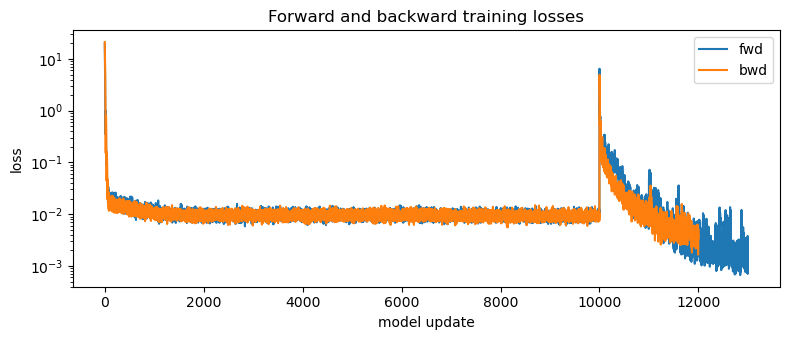

In [60]:
plt.figure(figsize=(8, 3.5))
plt.semilogy(fwd_losses, label='fwd')
plt.semilogy(bwd_losses, label='bwd')
plt.xlabel('model update')
plt.ylabel('loss')
plt.title('Forward and backward training losses')
plt.legend()
plt.tight_layout()
plt.show()

## Last Solved BVP Datasets

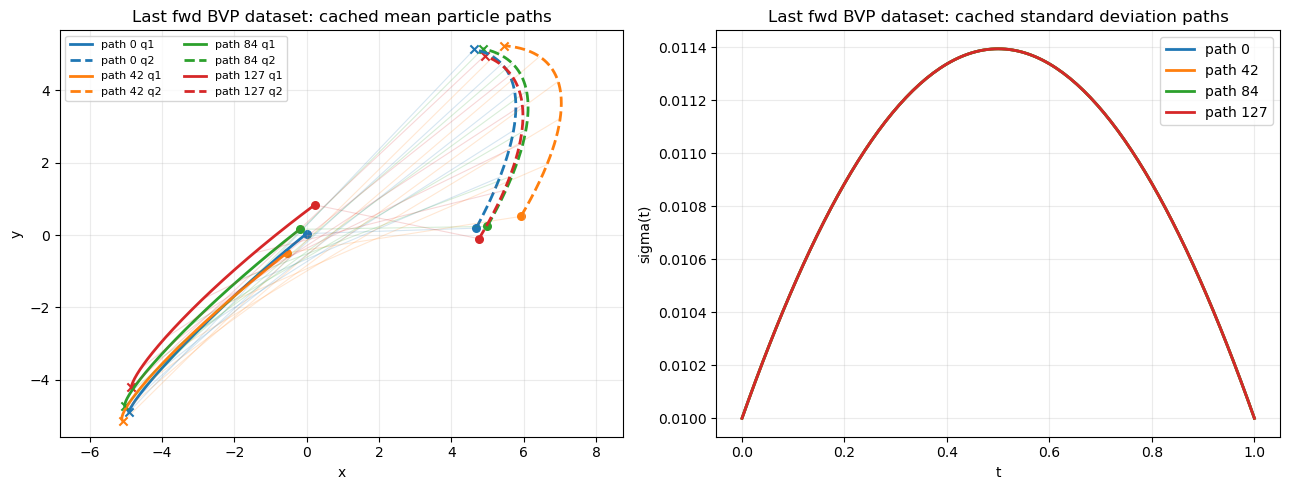

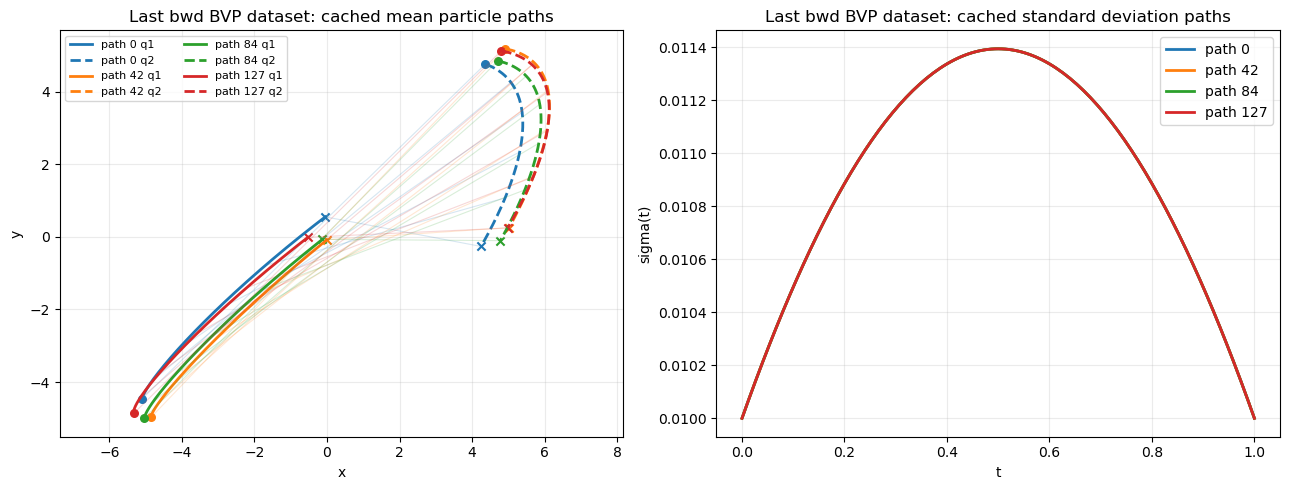

In [61]:
if last_fwd_states is not None:
    plot_cached_mean_std_paths(last_fwd_path, last_fwd_states, 'Last fwd BVP dataset')
if last_bwd_states is not None:
    plot_cached_mean_std_paths(last_bwd_path, last_bwd_states, 'Last bwd BVP dataset')

## Evaluation

In [62]:
fwd_model.eval()
bwd_model.eval()
fwd_node = make_node(fwd_model)
bwd_node = make_node(bwd_model)
eval_t_span = torch.linspace(0, 1, 100, device=device)

with torch.no_grad():
    fwd_traj = fwd_node.trajectory(sample_source(eval_batch), t_span=eval_t_span)
    bwd_traj = bwd_node.trajectory(sample_target(eval_batch), t_span=eval_t_span)

fwd_traj_plot = to_numpy(fwd_traj)
bwd_traj_plot = to_numpy(bwd_traj)
fwd_target_ref = to_numpy(sample_target(eval_batch))
bwd_source_ref = to_numpy(sample_source(eval_batch))

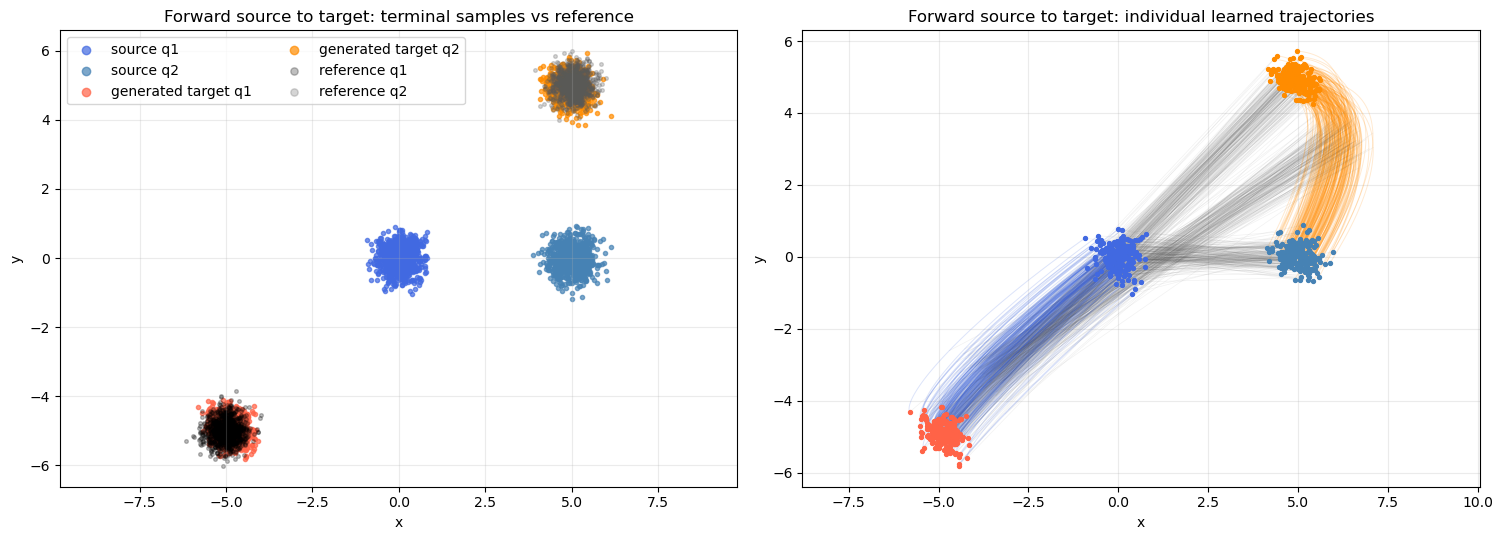

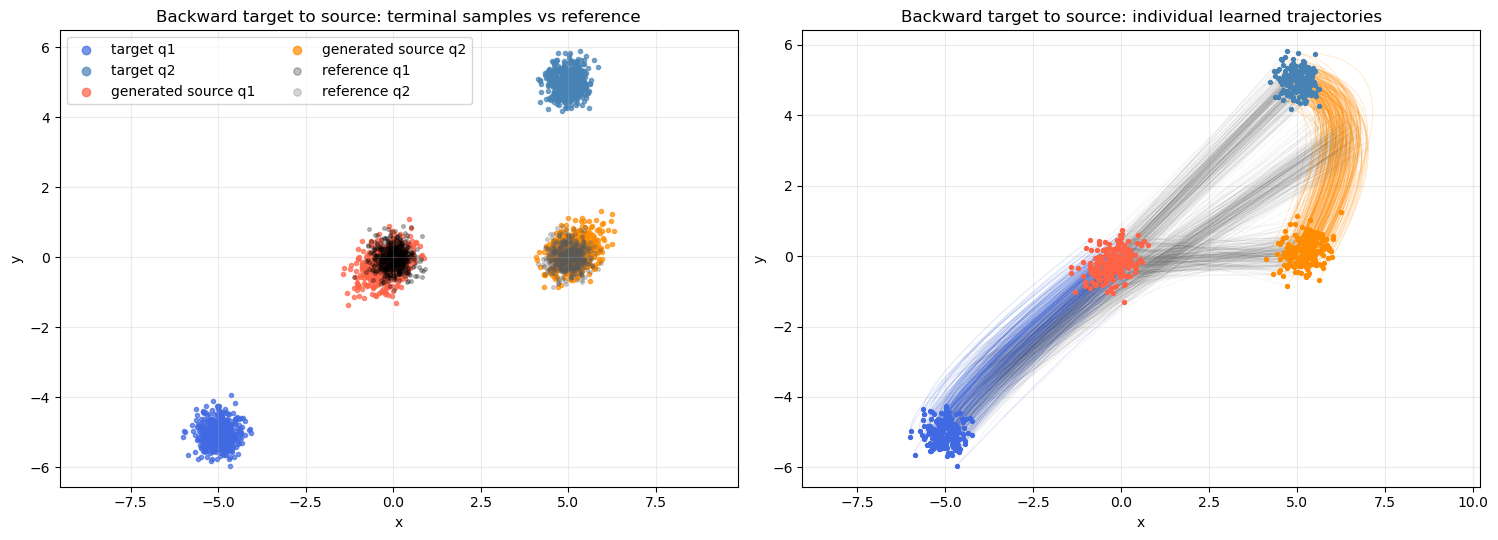

In [63]:
def plot_learned_particle_trajectories(traj_plot, reference, title, source_labels, terminal_labels, n_show=500, n_lines=200):
    n_show = min(n_show, traj_plot.shape[1])
    n_lines = min(n_lines, traj_plot.shape[1])
    traj_particles = traj_plot.reshape(traj_plot.shape[0], traj_plot.shape[1], n_particles, particle_dim)
    ref_particles = reference.reshape(reference.shape[0], n_particles, particle_dim)

    fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

    axes[0].scatter(traj_particles[0, :n_show, 0, 0], traj_particles[0, :n_show, 0, 1], s=9, c='royalblue', alpha=0.7, label=source_labels[0])
    axes[0].scatter(traj_particles[0, :n_show, 1, 0], traj_particles[0, :n_show, 1, 1], s=9, c='steelblue', alpha=0.7, label=source_labels[1])
    axes[0].scatter(traj_particles[-1, :n_show, 0, 0], traj_particles[-1, :n_show, 0, 1], s=9, c='tomato', alpha=0.7, label=terminal_labels[0])
    axes[0].scatter(traj_particles[-1, :n_show, 1, 0], traj_particles[-1, :n_show, 1, 1], s=9, c='darkorange', alpha=0.7, label=terminal_labels[1])
    axes[0].scatter(ref_particles[:n_show, 0, 0], ref_particles[:n_show, 0, 1], s=7, c='black', alpha=0.25, label='reference q1')
    axes[0].scatter(ref_particles[:n_show, 1, 0], ref_particles[:n_show, 1, 1], s=7, c='0.35', alpha=0.25, label='reference q2')
    axes[0].set_title(f'{title}: terminal samples vs reference')
    axes[0].legend(markerscale=2, ncols=2)

    for i in range(n_lines):
        axes[1].plot(traj_particles[:, i, 0, 0], traj_particles[:, i, 0, 1], color='royalblue', alpha=0.18, linewidth=0.7)
        axes[1].plot(traj_particles[:, i, 1, 0], traj_particles[:, i, 1, 1], color='darkorange', alpha=0.18, linewidth=0.7)
        for j in [0, traj_particles.shape[0] // 2, traj_particles.shape[0] - 1]:
            axes[1].plot(traj_particles[j, i, :, 0], traj_particles[j, i, :, 1], color='0.35', alpha=0.08, linewidth=0.5)
    axes[1].scatter(traj_particles[0, :n_lines, 0, 0], traj_particles[0, :n_lines, 0, 1], s=8, c='royalblue', zorder=3)
    axes[1].scatter(traj_particles[0, :n_lines, 1, 0], traj_particles[0, :n_lines, 1, 1], s=8, c='steelblue', zorder=3)
    axes[1].scatter(traj_particles[-1, :n_lines, 0, 0], traj_particles[-1, :n_lines, 0, 1], s=8, c='tomato', zorder=3)
    axes[1].scatter(traj_particles[-1, :n_lines, 1, 0], traj_particles[-1, :n_lines, 1, 1], s=8, c='darkorange', zorder=3)
    axes[1].set_title(f'{title}: individual learned trajectories')

    for ax in axes:
        ax.axis('equal')
        ax.grid(alpha=0.25)
        ax.set_xlabel('x')
        ax.set_ylabel('y')

    plt.tight_layout()
    plt.show()


plot_learned_particle_trajectories(
    fwd_traj_plot,
    fwd_target_ref,
    'Forward source to target',
    n_show = 1000,
    source_labels=('source q1', 'source q2'),
    terminal_labels=('generated target q1', 'generated target q2'),
)
plot_learned_particle_trajectories(
    bwd_traj_plot,
    bwd_source_ref,
    'Backward target to source',
    source_labels=('target q1', 'target q2'),
    terminal_labels=('generated source q1', 'generated source q2'),
)

In [64]:
def print_terminal_summary(name, generated_np, reference_mean, target_covariance):
    generated = torch.as_tensor(generated_np[-1], device=device, dtype=reference_mean.dtype)
    generated_mean = generated.mean(dim=0)
    generated_cov_diag = generated.var(dim=0, unbiased=True)

    print(f'{name} terminal mean:', generated_mean.tolist())
    print(f'{name} reference mean:', reference_mean.tolist())
    print(f'{name} covariance diagonal:', generated_cov_diag.tolist())
    print(f'{name} reference covariance diagonal:', [target_covariance] * dim)
    print(f'{name} mean error norm:', torch.linalg.norm(generated_mean - reference_mean).item())


print_terminal_summary('Forward', fwd_traj_plot, target_mean, covariance)
print_terminal_summary('Backward', bwd_traj_plot, source_mean, covariance)

Forward terminal mean: [-4.884027004241943, -4.907090663909912, 4.919475078582764, 4.93274450302124]
Forward reference mean: [-5.0, -5.0, 5.0, 5.0]
Forward covariance diagonal: [0.08905058354139328, 0.08624789118766785, 0.08516298979520798, 0.09026874601840973]
Forward reference covariance diagonal: [0.1, 0.1, 0.1, 0.1]
Forward mean error norm: 0.18190504610538483
Backward terminal mean: [-0.23888395726680756, -0.1883179098367691, 5.208226203918457, 0.14268843829631805]
Backward reference mean: [0.0, 0.0, 5.0, 0.0]
Backward covariance diagonal: [0.168217271566391, 0.14828409254550934, 0.16850773990154266, 0.14579828083515167]
Backward reference covariance diagonal: [0.1, 0.1, 0.1, 0.1]
Backward mean error norm: 0.3952813148498535


## Forward NODE vs Closed-Form Spring BVP

Sample fresh source configurations, transport them with the learned forward NODE, then solve the analytic spring boundary-value problem between each source sample and its generated terminal sample. This compares the learned trajectory against the exact deterministic Hamiltonian path for the same endpoints.

In [65]:
def closed_form_spring_path_batch(t_grid, q0_batch, q1_batch, kappa=1.0):
    q0_batch = q0_batch.to(device=device)
    q1_batch = q1_batch.to(device=q0_batch.device, dtype=q0_batch.dtype)
    t = torch.as_tensor(t_grid, dtype=q0_batch.dtype, device=q0_batch.device).reshape(-1, 1, 1)

    q0p = as_particles(q0_batch)
    q1p = as_particles(q1_batch)

    c0 = 0.5 * (q0p[:, 0] + q0p[:, 1])
    c1 = 0.5 * (q1p[:, 0] + q1p[:, 1])
    r0 = q0p[:, 1] - q0p[:, 0]
    r1 = q1p[:, 1] - q1p[:, 0]

    omega = torch.as_tensor(math.sqrt(2.0 * kappa), dtype=q0_batch.dtype, device=q0_batch.device)
    rdot0 = omega / torch.sin(omega) * (r1 - torch.cos(omega) * r0)

    c_t = (1.0 - t) * c0.unsqueeze(0) + t * c1.unsqueeze(0)
    r_t = torch.cos(omega * t) * r0.unsqueeze(0) + torch.sin(omega * t) / omega * rdot0.unsqueeze(0)
    q1_t = c_t - 0.5 * r_t
    q2_t = c_t + 0.5 * r_t
    return torch.stack([q1_t, q2_t], dim=2).reshape(t.shape[0], q0_batch.shape[0], dim)


fwd_model.eval()
fwd_node = make_node(fwd_model)

eval_x0 = sample_source(eval_batch)
with torch.no_grad():
    learned_traj = fwd_node.trajectory(eval_x0, t_span=eval_t_span)

generated_x1 = learned_traj[-1].detach()
closed_form_traj = closed_form_spring_path_batch(eval_t_span, eval_x0, generated_x1, kappa=kappa)

trajectory_rmse = torch.sqrt(torch.mean((learned_traj - closed_form_traj) ** 2)).item()
per_time_rmse = torch.sqrt(torch.mean((learned_traj - closed_form_traj) ** 2, dim=(1, 2)))
closed_form_start_error = torch.linalg.norm(closed_form_traj[0] - eval_x0, dim=-1).mean().item()
closed_form_end_error = torch.linalg.norm(closed_form_traj[-1] - generated_x1, dim=-1).mean().item()

print(f'Forward NODE vs closed-form BVP trajectory RMSE: {trajectory_rmse:.6e}')
print(f'Closed-form start endpoint mean error: {closed_form_start_error:.6e}')
print(f'Closed-form terminal endpoint mean error: {closed_form_end_error:.6e}')

Forward NODE vs closed-form BVP trajectory RMSE: 6.813604e-03
Closed-form start endpoint mean error: 1.203537e-07
Closed-form terminal endpoint mean error: 4.159459e-07


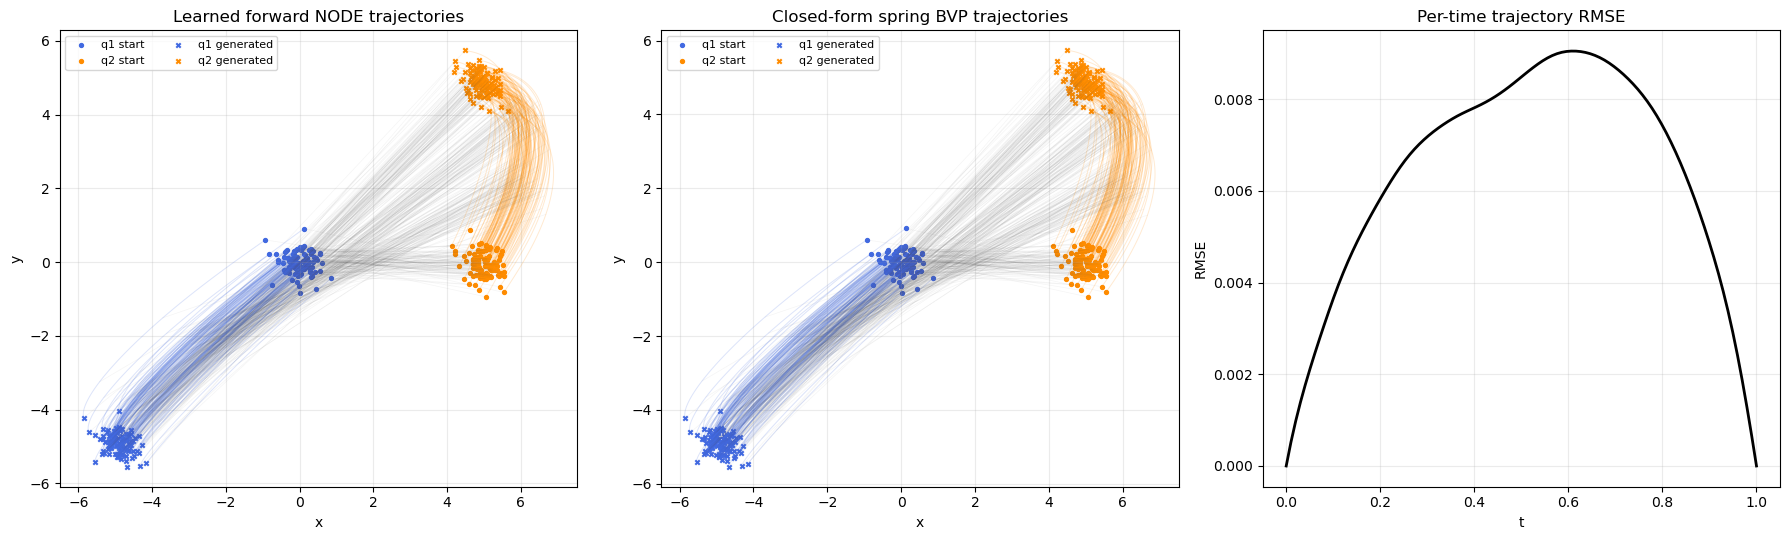

In [66]:
n_compare_lines = min(100, eval_batch)
learned_particles = to_numpy(as_particles(learned_traj[:, :n_compare_lines]))
closed_particles = to_numpy(as_particles(closed_form_traj[:, :n_compare_lines]))
time_rmse = to_numpy(per_time_rmse)
t_eval_plot = to_numpy(eval_t_span)
spring_idx = np.linspace(0, learned_particles.shape[0] - 1, 4).astype(int)

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

for i in range(n_compare_lines):
    axes[0].plot(learned_particles[:, i, 0, 0], learned_particles[:, i, 0, 1], color='royalblue', alpha=0.18, linewidth=0.7)
    axes[0].plot(learned_particles[:, i, 1, 0], learned_particles[:, i, 1, 1], color='darkorange', alpha=0.18, linewidth=0.7)
    axes[1].plot(closed_particles[:, i, 0, 0], closed_particles[:, i, 0, 1], color='royalblue', alpha=0.18, linewidth=0.7)
    axes[1].plot(closed_particles[:, i, 1, 0], closed_particles[:, i, 1, 1], color='darkorange', alpha=0.18, linewidth=0.7)
    for sidx in spring_idx:
        axes[0].plot(learned_particles[sidx, i, :, 0], learned_particles[sidx, i, :, 1], color='0.35', alpha=0.06, linewidth=0.5)
        axes[1].plot(closed_particles[sidx, i, :, 0], closed_particles[sidx, i, :, 1], color='0.35', alpha=0.06, linewidth=0.5)

axes[0].scatter(learned_particles[0, :, 0, 0], learned_particles[0, :, 0, 1], s=8, c='royalblue', label='q1 start')
axes[0].scatter(learned_particles[0, :, 1, 0], learned_particles[0, :, 1, 1], s=8, c='darkorange', label='q2 start')
axes[0].scatter(learned_particles[-1, :, 0, 0], learned_particles[-1, :, 0, 1], s=10, c='royalblue', marker='x', label='q1 generated')
axes[0].scatter(learned_particles[-1, :, 1, 0], learned_particles[-1, :, 1, 1], s=10, c='darkorange', marker='x', label='q2 generated')
axes[0].set_title('Learned forward NODE trajectories')

axes[1].scatter(closed_particles[0, :, 0, 0], closed_particles[0, :, 0, 1], s=8, c='royalblue', label='q1 start')
axes[1].scatter(closed_particles[0, :, 1, 0], closed_particles[0, :, 1, 1], s=8, c='darkorange', label='q2 start')
axes[1].scatter(closed_particles[-1, :, 0, 0], closed_particles[-1, :, 0, 1], s=10, c='royalblue', marker='x', label='q1 generated')
axes[1].scatter(closed_particles[-1, :, 1, 0], closed_particles[-1, :, 1, 1], s=10, c='darkorange', marker='x', label='q2 generated')
axes[1].set_title('Closed-form spring BVP trajectories')

axes[2].plot(t_eval_plot, time_rmse, color='black', linewidth=2.0)
axes[2].set_xlabel('t')
axes[2].set_ylabel('RMSE')
axes[2].set_title('Per-time trajectory RMSE')
axes[2].grid(alpha=0.25)

for ax in axes[:2]:
    ax.axis('equal')
    ax.grid(alpha=0.25)
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.legend(fontsize=8, ncols=2)

plt.tight_layout()
plt.show()